In [29]:
import numpy as np

# Return the (g,h) index of the BMU in the grid
def find_BMU(SOM, x, act=None):
    if np.all(act == None):
        act = np.array([1]*len(SOM[0,0]))
    distSq = (np.square(np.multiply(act, (SOM - x)))).sum(axis=2)
    g,h = np.unravel_index(np.argmin(distSq, axis=None), distSq.shape) # the function converts from linear to 2D index
    eucl_dist = distSq[g,h]
    return g,h,eucl_dist

In [30]:
# Update the weights of the SOM cells when given a single training example
# and the model parameters along with BMU coordinates as a tuple
def update_weights(SOM, train_ex, learn_rate, radius_sq,
                   BMU_coord, step=5):
    g, h = BMU_coord
    # if radius is close to zero then only BMU is changed
    if radius_sq < 1e-3:
        SOM[g, h, :] += learn_rate * (train_ex - SOM[g, h, :])
        return SOM
    # Change all cells in a small neighborhood of BMU
    for i in range(max(0, g - step), min(SOM.shape[0], g + step)):
        for j in range(max(0, h - step), min(SOM.shape[1], h + step)):
            dist_sq = np.square(i - g) + np.square(j - h)
            dist_func = np.exp(-dist_sq / (2 * radius_sq))
            # dist_func = np.exp(-dist_sq / radius_sq)
            # print(dist_func)
            SOM[i, j, :] += learn_rate * dist_func * (train_ex - SOM[i, j, :])
    return SOM

In [31]:
# Main routine for training an SOM. It requires an initialized SOM grid
# or a partially trained grid as parameter
def train_SOM(SOM, train_data, act = None, learn_rate=0.9, radius_sq=30,
              lr_decay=.1, radius_decay=.1, epochs=100):
    learn_rate_0 = learn_rate
    radius_0 = radius_sq
    for epoch in np.arange(0, epochs):
        rand.shuffle(train_data)
        qe=0
        for train_ex, i in zip(train_data,range(len(train_data))):
            g, h, ed = find_BMU(SOM, train_ex, act)
            qe+=ed
            SOM = update_weights(SOM, train_ex,
                                 learn_rate, radius_sq, (g, h))
        # print(qe/len(train_data))
        # Update learning rate and radius
        learn_rate = learn_rate_0 * np.exp(-epoch * lr_decay)
        # print("L_R=",learn_rate,"epoch=",epoch)
        radius_sq = radius_0 * np.exp(-epoch * radius_decay)
        # print("R_S=",radius_sq,"epoch=",epoch)
    return SOM

In [32]:
# Dimensions of the SOM grid
m = 20
n = 20
# Number of training examples
n_x = 6000
rand = np.random.RandomState(0)
# Initialize the training data
train_data = np.genfromtxt("animals.txt", delimiter=",",skip_header=True,usecols=range(1,14))
animals = np.genfromtxt("animals.txt", delimiter=",",skip_header=True,usecols=0,dtype="U")
attributes = np.genfromtxt("animals.txt", delimiter=",",usecols=range(1,13),dtype="U",skip_footer=16)
# Initialize the SOM randomly
SOM = np.random.rand(20,20,13)

In [33]:
a = np.array([1]*13)
a[4]=2
SOM = train_SOM(SOM, train_data, a, epochs=50)

In [34]:
def labels(SOM, train_data, lbl):
    label = np.array([["       "] * len(SOM[0])] * len(SOM[1]))
    # activity = np.array([[0] * 20] * 20).astype(float)
    # eucld = np.array([[0] * 20] * 20).astype(float)
    for x in range(len(SOM[0])):
        for y in range(len(SOM[1])):
            i = 0
            mindist = float("inf")
            for train_ex in train_data:
                d = np.sum(np.square(SOM[x, y] - train_ex))
                # a = np.exp2(d)
                if d < mindist:
                    mindist = d
                    label[x, y] = lbl[i]
                    # activity[x, y] = a
                    # eucld[x, y] = d
                i += 1
    return label

In [35]:
an_label = labels(SOM, train_data, animals)
# print(an_label)

In [42]:
nr = np.array(range(1,21))
row_format ="{:>10}" * (len(nr))
print(row_format.format("", *nr))
for n_, row in zip(nr,an_label):
    print(row_format.format(n_,*row))

                   1         2         3         4         5         6         7         8         9        10        11        12        13        14        15        16        17        18        19
         1      dove      dove     tiger     tiger     tiger     tiger     tiger     tiger      duck      duck      duck     eagle     eagle     eagle     eagle     horse     horse     horse     horse
         2      dove      dove      dove     tiger     tiger     tiger     tiger      duck      duck      duck      duck     eagle     eagle     eagle     eagle     eagle     horse     horse     horse
         3      dove      dove      dove     tiger     tiger     tiger      duck      duck      duck      duck      duck     eagle     eagle     eagle     eagle     eagle     horse     horse     horse
         4      dove      dove      dove     tiger     tiger      duck      duck      duck      duck      duck      duck     eagle     eagle     eagle     eagle     eagle     eagle     horse     h

In [37]:
def activity(label, names, SOM, train_data, act = None, act_norm = 0, sens = 1):
    if np.all(act == None):
        act = np.array([1]*len(SOM[0,0]))
    i = np.where(names == label)
    dist = (np.square(np.multiply(act, (SOM - train_data[i])))).sum(axis=2)
    activity = np.exp(-dist * sens)
    if act_norm == 0: # if we don't want normalized acitivity
        return activity
    elif act_norm == 1: # if we want normalized activity
        activity_n = activity/np.sum(activity)
        return activity_n

In [38]:
def activity_vec(vector, SOM, act = None, act_norm = 0, sens = 1):
    if np.all(act == None):
        act = np.array([1]*len(SOM[0,0]))
    dist = (np.square(np.multiply(act, (SOM - vector)))).sum(axis=2)
    activity = np.exp(-dist * sens)
    if act_norm == 0: # if we don't want normalized activity
        return activity
    elif act_norm == 1: # if we want normalized activity
        activity_n = activity/np.sum(activity)
        return activity_n

def act_output(vector, SOM, act = None, output = 0, sens = 1): # should I also have a parameter for normalized, unnormalized activity
    if np.all(act == None):
        act = np.array([1]*len(SOM[0,0]))
    if output == 0: # if we want "hard" output
        g, h, eucl_dist = find_BMU(SOM, vector, act)
        return SOM[g,h]
    elif output == 1: # if we want "soft" output
        activity_n = activity_vec(vector, SOM, act, 1, sens)
        sm = np.zeros(13)
        for i, row in zip(range(len(activity_n[0])), activity_n): # maybe this could aslo be done in just a line?
            for j, neuron in zip(range(len(activity_n[1])), row):
                sm += np.multiply(neuron,SOM[i,j])
        return sm

In [39]:
a = activity("cat", animals, SOM, train_data)
#print(a)

In [40]:
bi = activity_vec(vector=np.array([0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0]), SOM=SOM, act = np.array([1,1,1,1,1,1,1,1,1,1,1,1,1]), act_norm=1, sens = 10)
print(bi)

[[4.00171618e-18 3.70677931e-17 1.49317253e-15 9.15765965e-15
  1.43062168e-14 3.87034415e-14 1.48061712e-13 2.23253182e-13
  1.06969887e-13 3.97299117e-17 8.25389069e-19 2.17234110e-22
  3.06778748e-33 8.90426727e-36 4.77255123e-37 8.59911103e-38
  5.97901334e-39 5.18739400e-40 7.74873618e-41 7.44259529e-41]
 [1.73382275e-18 1.26035391e-17 8.39959664e-16 1.09071573e-14
  2.97596792e-14 1.23382600e-13 2.33765946e-13 6.01077830e-14
  1.08294733e-14 5.04045246e-17 6.34063103e-19 1.31200845e-23
  3.63277182e-35 2.58080001e-36 9.35868783e-37 2.56135877e-37
  1.64703544e-38 7.97855664e-40 7.64368871e-41 7.44114711e-41]
 [6.56121736e-18 3.92641019e-17 2.00882008e-15 3.87154806e-14
  1.72791698e-13 2.52569774e-13 2.67645297e-14 1.12173162e-15
  3.99797482e-16 5.72032498e-17 5.41210620e-19 5.10512725e-25
  4.84991303e-36 1.80738693e-36 2.40976604e-36 2.02172954e-36
  4.57524492e-37 2.72923519e-38 1.33254815e-39 7.55683103e-40]
 [8.24118848e-17 3.02360651e-16 5.88508068e-15 7.71560157e-14
  1.9

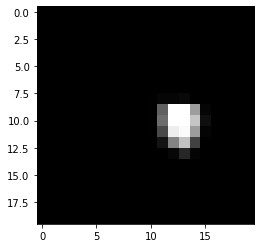

In [41]:
import matplotlib.pyplot as plt

plt.imshow(bi, cmap='gray')
plt.show()

In [19]:
c = act_output(vector=np.array([1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0]), SOM=SOM, act = np.array([0,0,1,1,1,1,1,1,1,1,1,1,1]), output=1, sens = 10)
print(c)

[3.65740324e-01 6.15821282e-01 1.84383812e-02 3.86374786e-02
 9.61362543e-01 9.61362540e-01 1.84317284e-02 7.60164566e-07
 3.86374751e-02 9.20642003e-01 2.22962939e-02 3.86374570e-02
 3.86373393e-02]


In [17]:
c = act_output(vector=np.array([1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0]), SOM=SOM, output=1, sens = 10)
print(c)

[9.19342140e-01 8.06578177e-02 4.39453870e-08 5.45866210e-02
 9.45413375e-01 9.45413379e-01 4.91914691e-08 7.07268929e-09
 5.45866240e-02 9.45231233e-01 1.82107082e-04 5.45866269e-02
 5.45866197e-02]


In [13]:
c = act_output(vector=np.array([1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0]), SOM=SOM, output=0)
print(c)

[9.65007419e-01 3.49925849e-02 2.30380044e-09 2.48175466e-02
 9.75182443e-01 9.75182457e-01 1.53187350e-08 1.71530833e-08
 2.48175585e-02 9.75182441e-01 1.54666512e-08 2.48175653e-02
 2.48175421e-02]


In [14]:
c = act_output(vector=np.array([1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0]), SOM=SOM, output=1)
print(c)

[0.42448357 0.38502936 0.1904871  0.1679936  0.83200642 0.8320064
 0.05856527 0.13835328 0.16799359 0.73370818 0.32341108 0.15813089
 0.08510073]


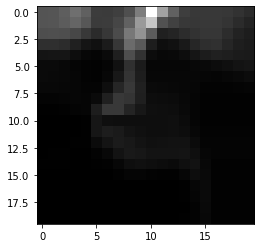

In [22]:
# to visualize the activity of data
import matplotlib.pyplot as plt

plt.imshow(b, cmap='gray')
plt.show()